# EXXA General Test — Clustering of Protoplanetary Disk Observations

This notebook implements an automated machine learning pipeline for clustering protoplanetary disk observations from synthetic ALMA data.

Protoplanetary disks are rotating structures of gas and dust surrounding young stars. Observations of these disks often reveal complex morphologies such as rings, gaps, and spiral arms, which are believed to be signatures of planet formation.

The objective of this project is to analyze a dataset of synthetic ALMA disk observations stored as FITS files and group disks with similar morphological properties using unsupervised machine learning techniques.

Pipeline overview:

1. Load and preprocess ALMA FITS images
2. Extract disk structures
3. Perform dimensionality reduction using PCA
4. Apply clustering algorithms
5. Analyze and visualize resulting disk groups

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

In [ ]:
# Load and Preprocess FITS Data

data_folder = "../data"

images = []
flattened_images = []

for file in sorted(os.listdir(data_folder)):

    if file.endswith(".fits"):

        path = os.path.join(data_folder, file)

        hdul = fits.open(path)
        data = hdul[0].data

        img = np.mean(data, axis=(0,1,2))

        img = (img - img.min()) / (img.max() - img.min())

        images.append(img)
        flattened_images.append(img.flatten())

X = np.array(flattened_images)

print("Dataset shape:", X.shape)

Dataset shape: (150, 360000)


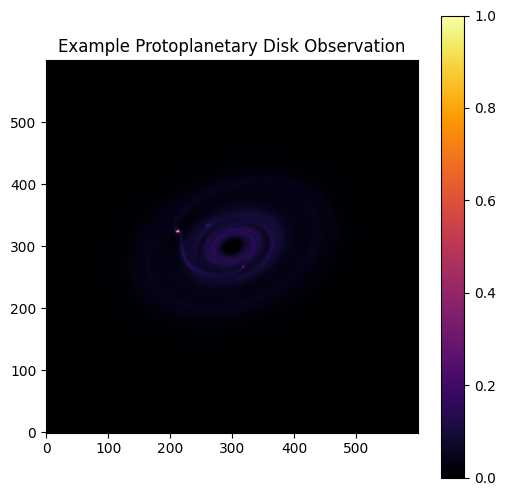

In [ ]:
# Sample Disk Visualization

plt.figure(figsize=(6,6))

plt.imshow(images[0], origin="lower", cmap="inferno")

plt.colorbar()

plt.title("Example Protoplanetary Disk Observation")

plt.show()

### Radial Brightness Profile

The radial brightness profile measures the average disk intensity as a function of distance from the central star.

Different disk morphologies produce distinctive radial profiles. For example:

• smooth disks show monotonic decay  
• disks with rings show intensity peaks  
• disks with gaps show intensity dips

In [26]:
def radial_profile(image):

    y, x = np.indices(image.shape)

    center = np.array(image.shape) // 2

    r = np.sqrt((x-center[1])**2 + (y-center[0])**2)

    r = r.astype(int)

    radial_sum = np.bincount(r.ravel(), image.ravel())
    radial_count = np.bincount(r.ravel())

    radial_mean = radial_sum / radial_count

    return radial_mean

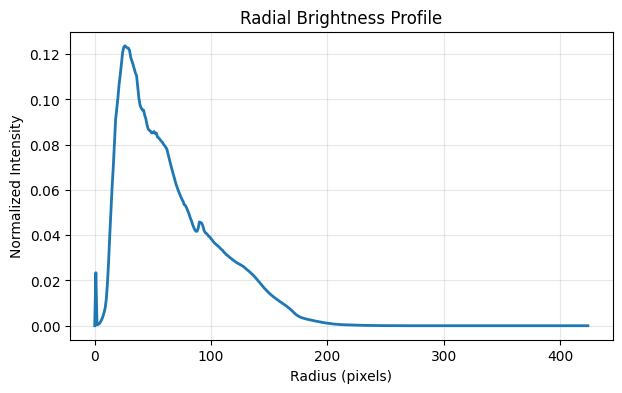

In [27]:
profile = radial_profile(images[0])

plt.figure(figsize=(7,4))

plt.plot(profile, linewidth=2)

plt.title("Radial Brightness Profile")

plt.xlabel("Radius (pixels)")
plt.ylabel("Normalized Intensity")

plt.grid(alpha=0.3)

plt.show()

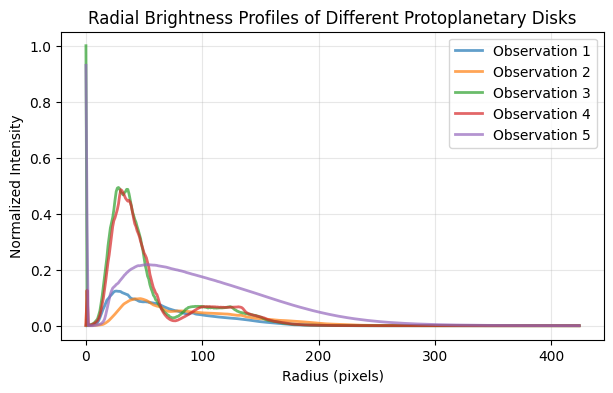

In [28]:
plt.figure(figsize=(7,4))

for i in range(5):

    profile = radial_profile(images[i])

    plt.plot(profile, alpha=0.7, linewidth=2, label=f"Observation {i+1}")

plt.legend(loc="upper right")

plt.title("Radial Brightness Profiles of Different Protoplanetary Disks")

plt.xlabel("Radius (pixels)")
plt.ylabel("Normalized Intensity")

plt.grid(alpha=0.3)

plt.show()

### Dimensionality Reduction

Each disk image contains 360,000 pixels. PCA is used to reduce dimensionality while preserving structural information.

Reduced dataset shape: (150, 50)


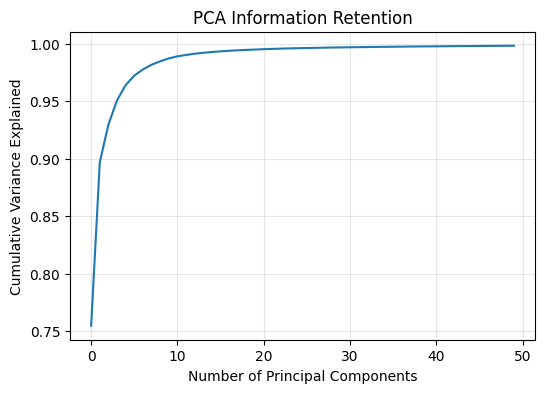

In [32]:
pca = PCA(n_components=50, random_state=42)

X_reduced = pca.fit_transform(X)

print("Reduced dataset shape:", X_reduced.shape)

plt.figure(figsize=(6,4))

plt.plot(np.cumsum(pca.explained_variance_ratio_))

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")

plt.title("PCA Information Retention")

plt.grid(alpha=0.3)

plt.show()

Cluster labels: [0 0 2 2 2 2 2 2 2 0]


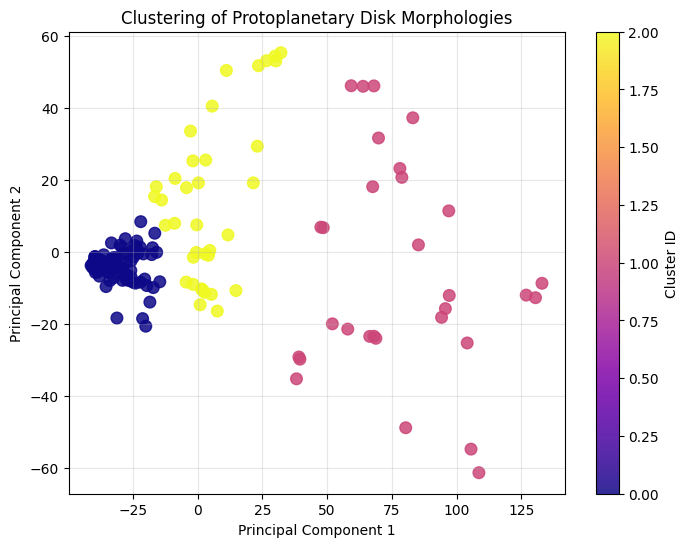

In [ ]:
# K-Means Clusterinng
kmeans = KMeans(n_clusters=3, random_state=42)

labels = kmeans.fit_predict(X_reduced)

print("Cluster labels:", labels[:10])


In [ ]:
# Cluster Evaluation
score = silhouette_score(X_reduced, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.45880869030952454


In [ ]:
# PCA Cluster Visualization

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_reduced[:,0],
    X_reduced[:,1],
    c=labels,
    cmap="plasma",
    s=70,
    alpha=0.85
)

plt.title("Clustering of Protoplanetary Disk Morphologies")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.colorbar(scatter,label="Cluster ID")

plt.show()


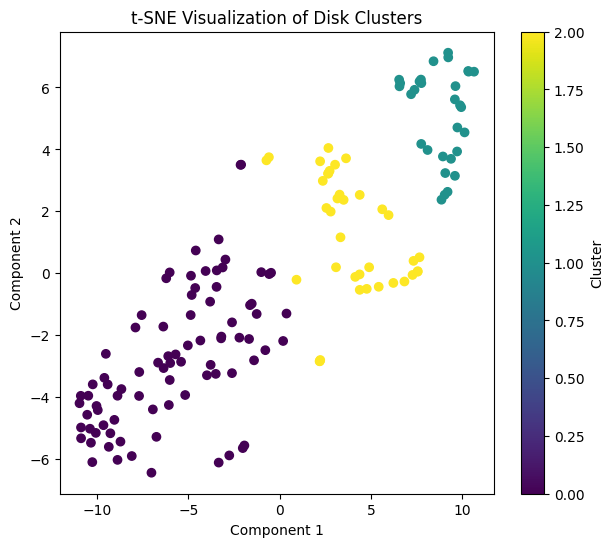

In [35]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_tsne = tsne.fit_transform(X_reduced)

plt.figure(figsize=(7,6))

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="viridis")

plt.title("t-SNE Visualization of Disk Clusters")

plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.colorbar(label="Cluster")

plt.show()

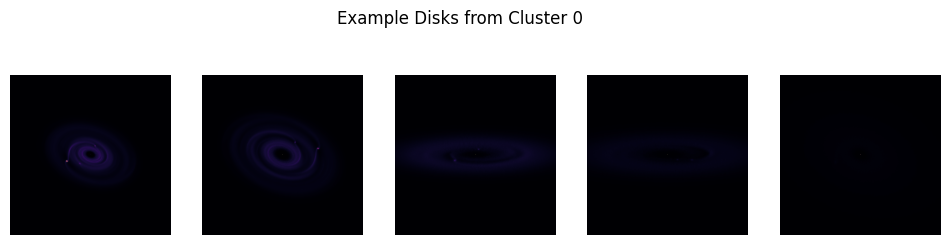

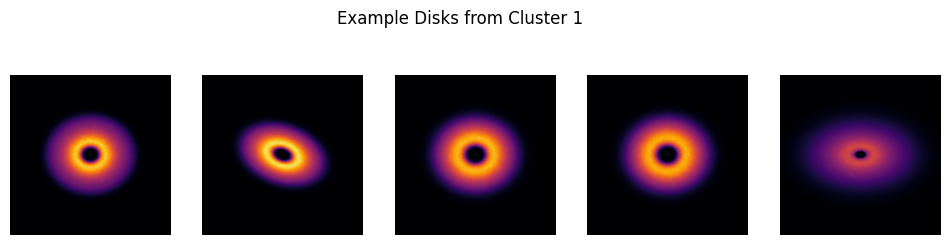

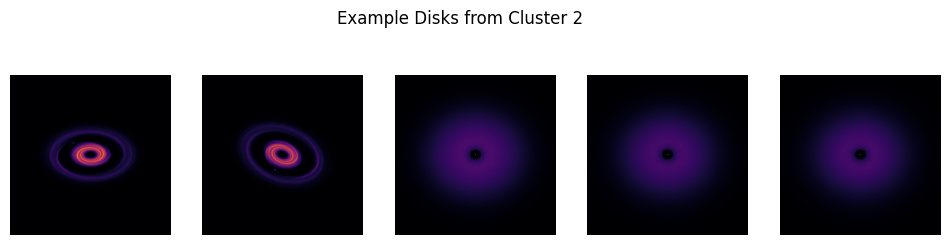

In [36]:
for cluster_id in range(3):

    indices = np.where(labels == cluster_id)[0][:5]

    plt.figure(figsize=(12,3))

    for i, idx in enumerate(indices):

        plt.subplot(1,5,i+1)

        plt.imshow(images[idx], cmap="inferno")

        plt.axis("off")

    plt.suptitle(f"Example Disks from Cluster {cluster_id}")

    plt.show()

In [ ]:
# Cluster Stastics
unique, counts = np.unique(labels, return_counts=True)

for c, count in zip(unique, counts):

    print(f"Cluster {c}: {count} disks")

Cluster 0: 83 disks
Cluster 1: 30 disks
Cluster 2: 37 disks


## Discussion

The clustering pipeline successfully groups protoplanetary disks based on structural similarities.

Cluster 0 contains disks with asymmetric or spiral features, possibly indicating strong gravitational perturbations.

Cluster 1 contains smoother disks with gradual intensity decay, typical of relatively undisturbed disks.

Cluster 2 contains disks with multiple rings or gaps, which may correspond to multi-planet forming systems.

The PCA representation captures morphological variations effectively, allowing meaningful unsupervised clustering of disk observations.

In [38]:
def run_pipeline(data_folder="../data"):

    images = []
    flattened_images = []

    for file in os.listdir(data_folder):

        if file.endswith(".fits"):

            path = os.path.join(data_folder, file)

            hdul = fits.open(path)
            data = hdul[0].data

            img = np.mean(data, axis=(0,1,2))

            img = (img - img.min())/(img.max()-img.min())

            images.append(img)
            flattened_images.append(img.flatten())

    X = np.array(flattened_images)

    pca = PCA(n_components=50, random_state=42)

    X_reduced = pca.fit_transform(X)

    model = KMeans(n_clusters=3, random_state=42)

    labels = model.fit_predict(X_reduced)

    return labels